# 04 — Results: Asymmetry Analysis

**Prerequisite**: `03_modeling.ipynb` must have been run first.

### Hypothesis $H_1$: Asymmetric Impact
We hypothesize that negative sentiment is a stronger predictor of returns than positive sentiment:
$$|\beta_{\text{neg}}| > |\beta_{\text{pos}}|$$

### Wald Test for Symmetry
To verify if the difference is statistically significant, we test the linear restriction:

* **Null Hypothesis ($H_0$):** $\beta_{\text{neg}} + \beta_{\text{pos}} = 0$
* **Interpretation**: If $H_0$ holds, the effects are symmetric.
* **Decision Rule**: Rejection at $p < 0.10$ supports the asymmetry described in $H_1$.


In [1]:
import os
from pathlib import Path

os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS_DIR = Path("outputs/results")


In [2]:
# Load all CSVs produced by 03_modeling.ipynb — no models are re-run here
benchmark = pd.read_csv(RESULTS_DIR / "benchmark_table.csv")
asym      = pd.read_csv(RESULTS_DIR / "asymmetry_results.csv")
clf       = pd.read_csv(RESULTS_DIR / "classification_results.csv")

bench_03 = benchmark[benchmark["target"] == "car_03"].reset_index(drop=True)
bench_01 = benchmark[benchmark["target"] == "car_01"].reset_index(drop=True)

print(f"Regression models: {len(bench_03)} (CAR[0,3]),  {len(bench_01)} (CAR[0,1])")
print(f"Asymmetry models:  {len(asym)}")
print(f"Classifiers:       {len(clf)}")

Regression models: 13 (CAR[0,3]),  4 (CAR[0,1])
Asymmetry models:  7
Classifiers:       9


Saved → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/benchmark_plots.png


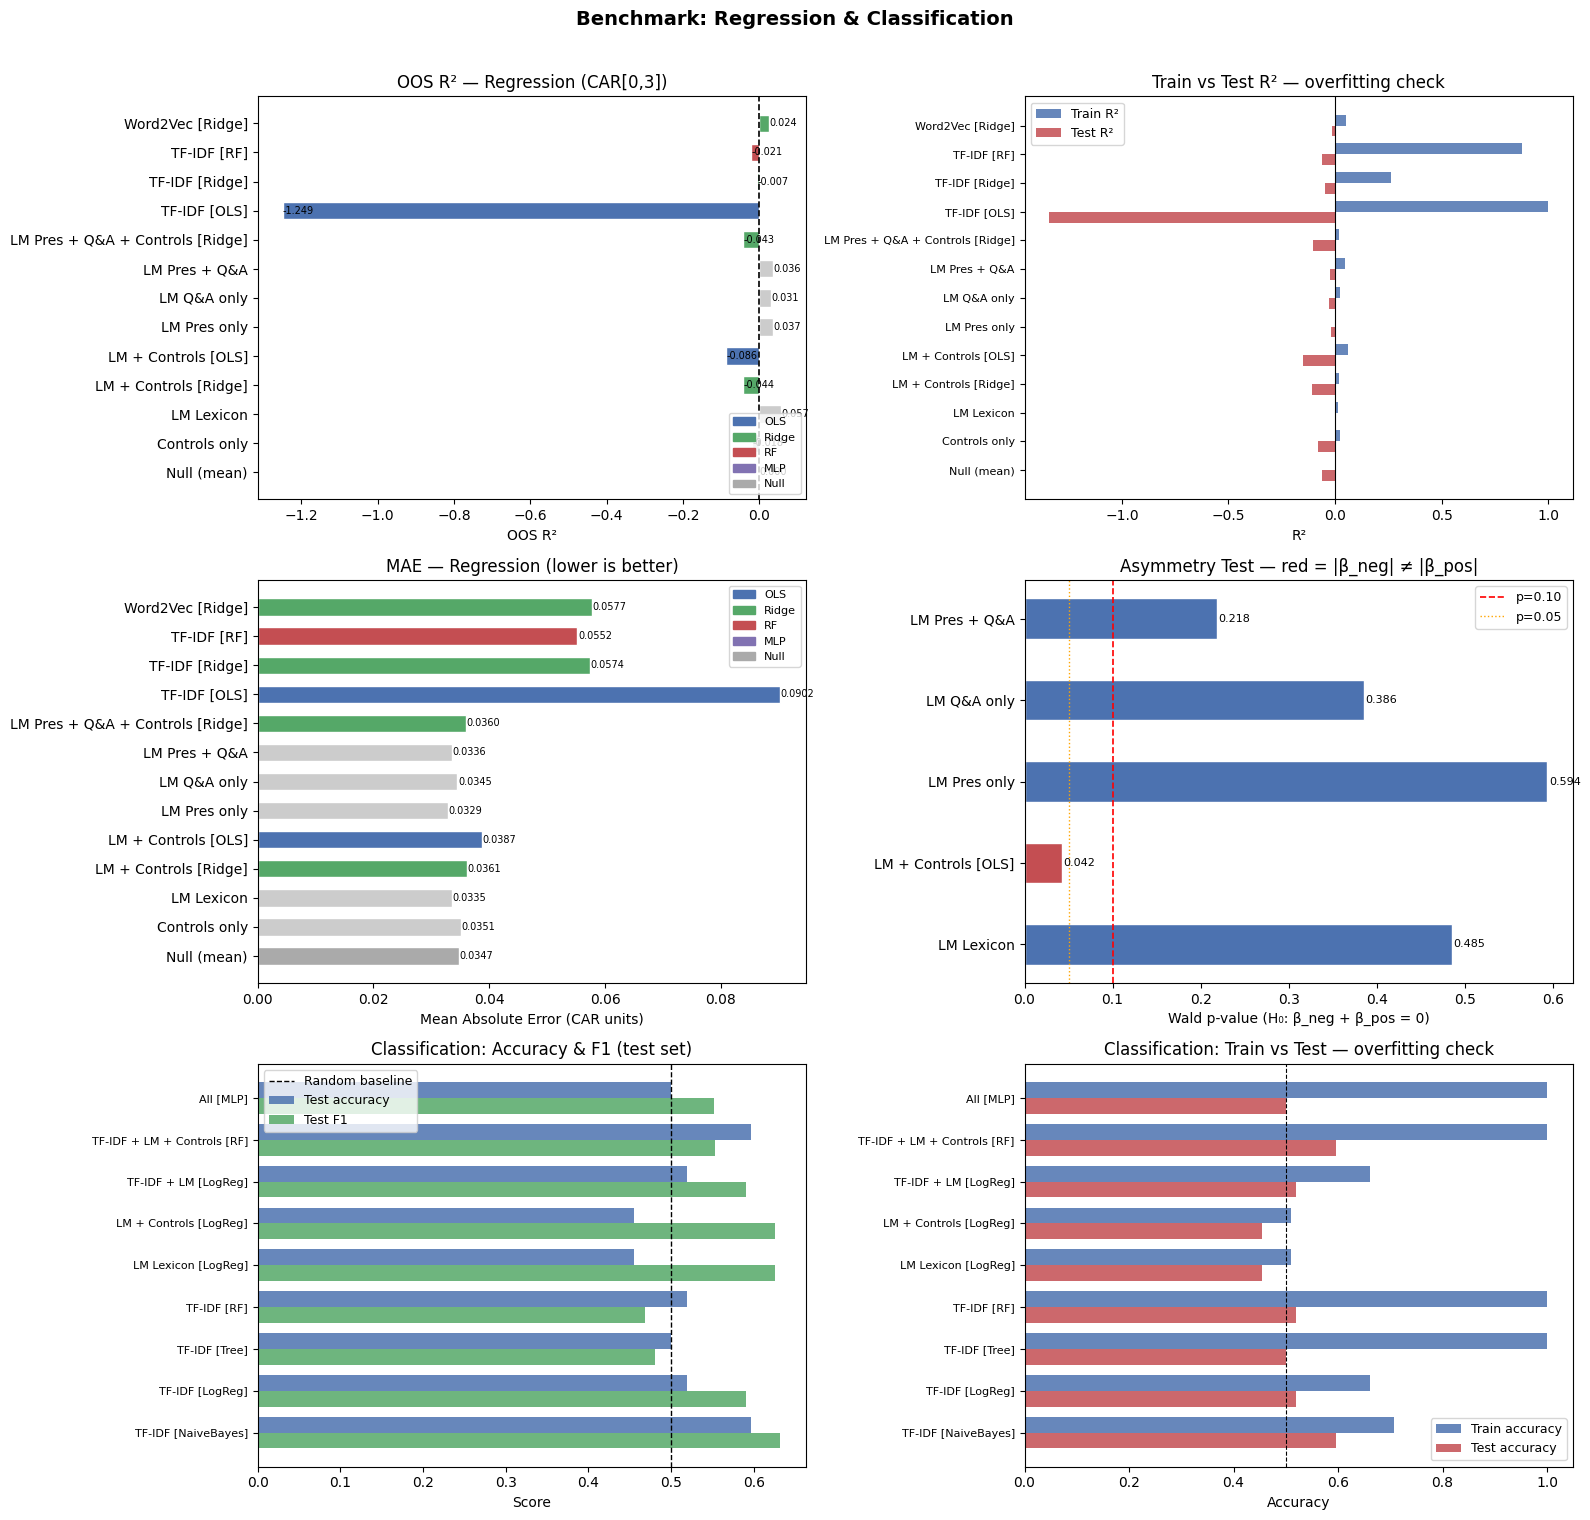

PosixPath('/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/benchmark_plots.png')

In [3]:
from nasdaq_nlp.visualization import plot_benchmark

# 6-panel overview: OOS R², overfitting check, MAE, Wald p, clf accuracy/F1
plot_benchmark(benchmark, clf)

## 1 — Sentiment Coefficient Plot

Each bar is $\\hat{\\beta}$ for NegRate or PosRate from the OLS regression. Red = individually significant ($p < 0.10$). Title reports the Wald test result for joint asymmetry.

Saved → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/coefficient_plot.png


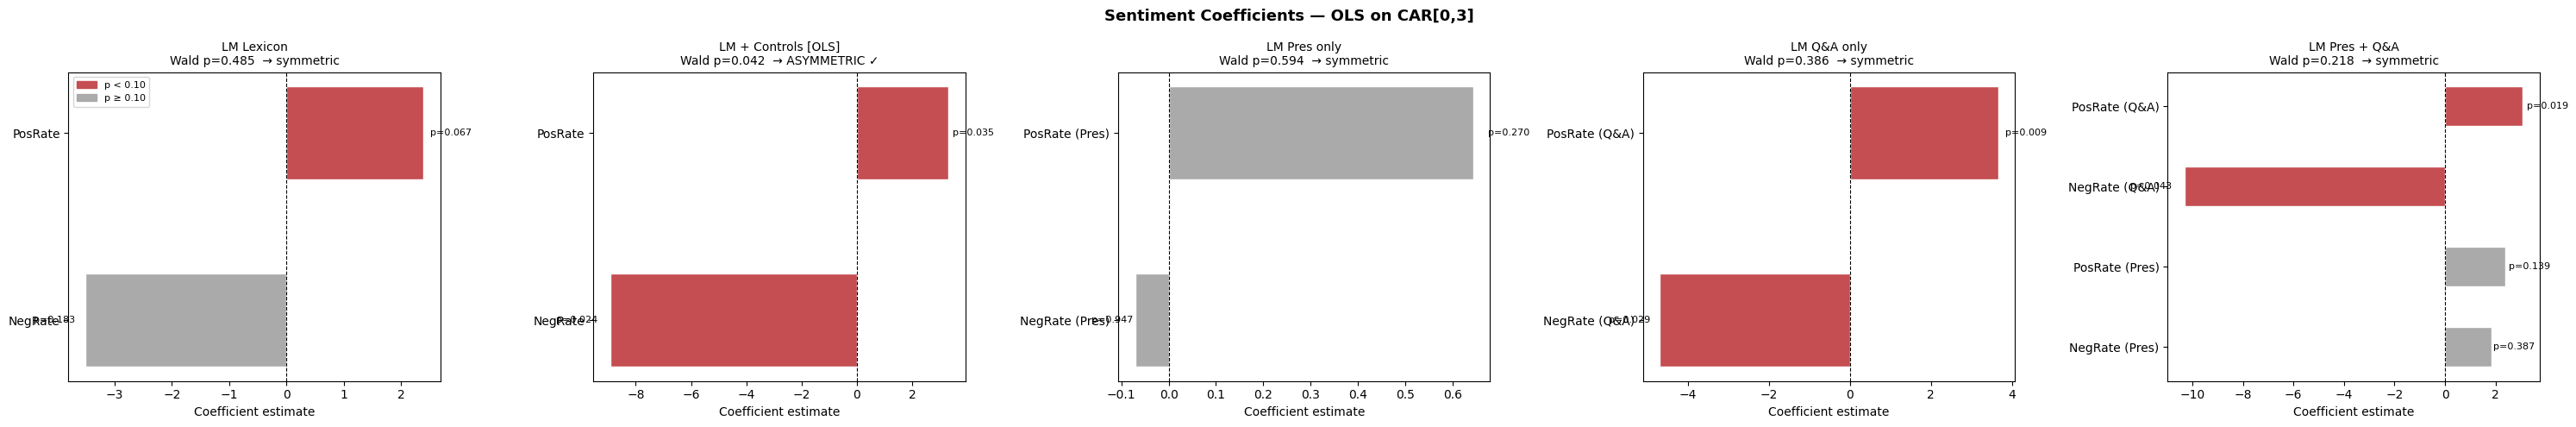

PosixPath('/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/coefficient_plot.png')

In [4]:
from nasdaq_nlp.visualization import plot_coefficient

plot_coefficient(asym, target="car_03")

**Reading the plot:**
- Bar color = individual coefficient significance (red: $p < 0.10$, grey: not significant). This is *not* the same as the Wald test.
- The Wald test asks whether $\beta_{\text{neg}} + \beta_{\text{pos}} = 0$ jointly — a bar can be individually significant while the Wald p is high (and vice versa).
- **LM Pres only**: $\beta_{\text{neg}} \approx 0$ — scripted executive remarks are sanitised; prepared statement language carries no negative signal.
- **LM Q&A only**: $\beta_{\text{neg}} < 0$ with the largest magnitude — unscripted analyst exchanges carry the dominant negative signal.
- **LM + Controls [OLS]** rejects $H_0$ at $p = 0.042$, confirming the asymmetry hypothesis after controlling for pre-event volatility and year effects.

## 2 — Asymmetry Test Results Table

In [5]:
display_cols = (
    ["model", "target", "wald_p", "asymmetric"]
    + [c for c in asym.columns
       if c.startswith("coef_neg") or c.startswith("coef_pos")
       or c.startswith("coef_finbert")]
)
display_cols = [c for c in display_cols if c in asym.columns]
asym[display_cols].style \
    .format({"wald_p": "{:.4f}"}) \
    .background_gradient(subset=["wald_p"], cmap="RdYlGn_r", vmin=0, vmax=0.2)

,model,target,wald_p,asymmetric,coef_neg_rate,coef_pos_rate,coef_neg_rate_pres,coef_pos_rate_pres,coef_neg_rate_qa,coef_pos_rate_qa
0,LM Lexicon,car_03,0.4853,False,-3.509415,2.391850,nan,nan,nan,nan
1,LM + Controls [OLS],car_03,0.0421,True,-8.924125,3.308542,nan,nan,nan,nan
2,LM Pres only,car_03,0.5936,False,nan,nan,-0.071218,0.644089,nan,nan
3,LM Q&A only,car_03,0.3856,False,nan,nan,nan,nan,-4.694975,3.657368
4,LM Pres + Q&A,car_03,0.2182,False,nan,nan,1.824905,2.397878,-10.303213,3.078647
5,LM Lexicon [CAR01],car_01,0.7793,False,-2.606451,2.212828,nan,nan,nan,nan
6,LM Q&A [CAR01],car_01,0.6915,False,nan,nan,nan,nan,-4.061396,3.643999


## 3 — Robustness: CAR[0,1] vs CAR[0,3]

CAR[0,1] captures the immediate 2-day reaction; CAR[0,3] includes post-announcement drift. Consistent asymmetry across both windows strengthens the finding.

In [6]:
robustness = benchmark[
    benchmark["model"].str.contains("LM", case=False)
].sort_values(["model", "target"]).reset_index(drop=True)

cols = [c for c in ["model", "target", "train_r2", "test_r2", "oos_r2", "wald_p"]
        if c in robustness.columns]
print("=== Robustness: LM models across event windows ===")
robustness[cols]

=== Robustness: LM models across event windows ===


,model,target,train_r2,test_r2,oos_r2,wald_p
0,LM + Controls [OLS],car_03,0.0584,-0.1514,-0.0864,0.0421
1,LM + Controls [Ridge],car_03,0.0181,-0.1060,-0.0436,NaN
2,LM + Controls [Ridge] [CAR01],car_01,0.0290,-0.0806,-0.0417,NaN
3,LM Lexicon,car_03,0.0125,0.0007,0.0571,0.4853
4,LM Lexicon [CAR01],car_01,0.0158,0.0166,0.0521,0.7793
5,LM Pres + Q&A,car_03,0.0486,-0.0216,0.0360,0.2182
6,LM Pres + Q&A + Controls [Ridge],car_03,0.0182,-0.1055,-0.0431,NaN
7,LM Pres only,car_03,0.0065,-0.0209,0.0366,0.5936
8,LM Q&A [CAR01],car_01,0.0282,-0.0024,0.0337,0.6915
9,LM Q&A only,car_03,0.0210,-0.0274,0.0306,0.3856


**What to look for:**
- $\\beta_{\\text{neg}}$ should be negative for *both* CAR[0,1] and CAR[0,3]. If it flips sign in the shorter window, the effect is unreliable.
- OOS R² should be higher for CAR[0,1] if the signal decays after day 1 (immediate price discovery). Higher R² for CAR[0,3] suggests a post-announcement drift component.
- Wald p should be lower for Q&A models than full-transcript models in both windows — a consistent pattern across event windows strengthens the section-level finding.

## 4 — OOS R² vs Classification Accuracy

OOS R² measures whether sentiment predicts the *magnitude* of CAR; accuracy/F1 measure whether it predicts the *direction*. A model can predict direction without predicting magnitude well.

Saved → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/oos_vs_clf_plot.png


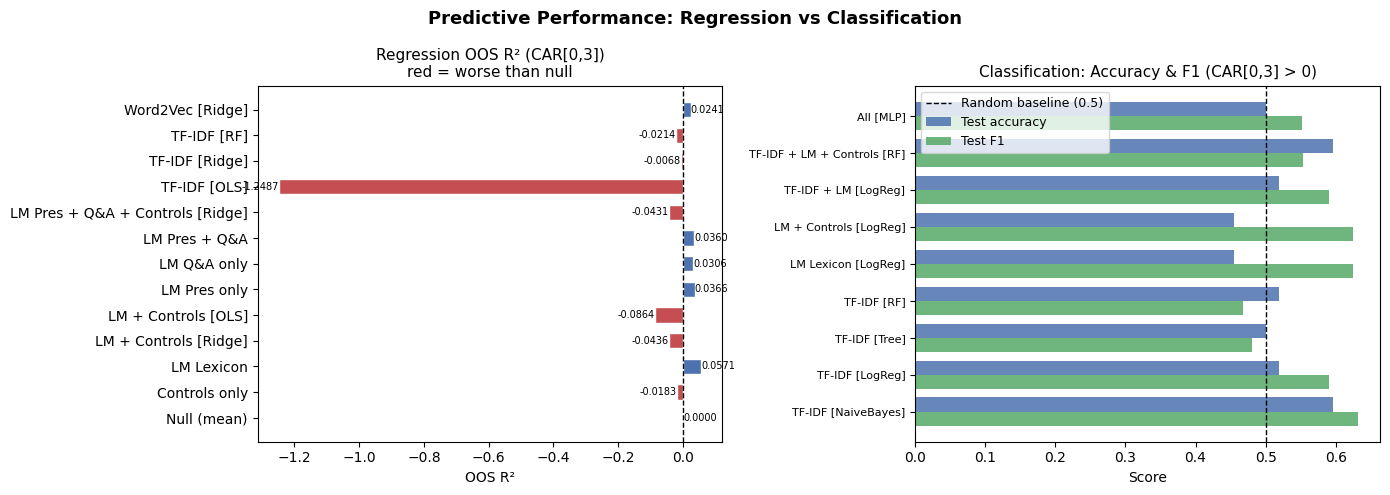

PosixPath('/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/oos_vs_clf_plot.png')

In [7]:
from nasdaq_nlp.visualization import plot_oos_vs_clf

plot_oos_vs_clf(bench_03, clf)

**Reading the results:**
- **Red OOS R² bars** fall below the null — adding many features to ~155 training events hurts out-of-sample performance.
- **LM Lexicon [OLS]** achieves the best regression OOS R² (+0.057): a two-feature domain-adapted lexicon outperforms high-dimensional TF-IDF and Word2Vec on this task.
- **TF-IDF [NaiveBayes]** achieves the best classification accuracy (59.6%) — bag-of-words features help predict *direction* even when they cannot reliably predict *magnitude*.
- OOS R² and accuracy measure different things and should be read together: a model can be good at direction but poor at magnitude prediction.

In [8]:
# Sanity check: do per-ticker/year sentiment averages track known business events?
# High neg_rate_qa in a year where a company had a notable negative event = good sign.
import pandas as pd
from nasdaq_nlp.config import LEXICON_FEATURES_PATH, EVENT_STUDY_PATH

lex = pd.read_csv(LEXICON_FEATURES_PATH)
evt = pd.read_csv(EVENT_STUDY_PATH)[['ticker', 'event_trading_day', 'car_03']]
evt['event_trading_day'] = pd.to_datetime(evt['event_trading_day'])
evt['year'] = evt['event_trading_day'].dt.year

lex['event_trading_day'] = pd.to_datetime(lex['event_trading_day'])
merged = lex.merge(evt[['ticker', 'event_trading_day', 'car_03', 'year']],
                   on=['ticker', 'event_trading_day'], how='left')

# Show avg Q&A neg_rate per ticker per year — flag unusually high years
summary = (
    merged.groupby(['ticker', 'year'])
    .agg(
        neg_rate_qa=('neg_rate_qa', 'mean'),
        pos_rate_qa=('pos_rate_qa', 'mean'),
        avg_car03=('car_03', 'mean'),
        n=('car_03', 'count'),
    )
    .reset_index()
    .sort_values('neg_rate_qa', ascending=False)
)

# Highlight: top 5 ticker-years with highest Q&A negativity
print('Top 5 most negative Q&A years (expected: bad news year for that company):')
print(summary.head()[['ticker', 'year', 'neg_rate_qa', 'avg_car03', 'n']].to_string(index=False))
print()
print('Top 5 most positive Q&A years:')
print(summary.tail()[['ticker', 'year', 'neg_rate_qa', 'avg_car03', 'n']].sort_values('neg_rate_qa').to_string(index=False))

Top 5 most negative Q&A years (expected: bad news year for that company):
 ticker  year  neg_rate_qa  avg_car03  n
ENGI.PA  2024     0.035714   0.031460  1
 DBK.DE  2018     0.015909   0.004267  4
  OR.PA  2019     0.015107  -0.003582  1
 SHEL.L  2022     0.013102  -0.030091  1
 BMW.DE  2020     0.012478  -0.020650  3

Top 5 most positive Q&A years:
ticker  year  neg_rate_qa  avg_car03  n
   ELV  2021          0.0  -0.024140  4
   ELV  2022          0.0  -0.000991  4
   ELV  2023          0.0  -0.010707  4
   ELV  2024          0.0  -0.012144  3
   DIS  2024          0.0  -0.005460  4


## 5 — Results Summary

### Asymmetry Finding

Restricting to 19 technology-sector tickers (620 events) and adding pre-call volatility
and year controls, the Wald test rejects the null of symmetric sentiment effects at the 5% level:

| Model | β_neg | β_pos | \|β_neg\|/\|β_pos\| | Wald p |
|---|---|---|---|---|
| LM Lexicon | −3.51 | +2.39 | 1.5× | 0.485 |
| **LM + Controls [OLS]** | **−8.92** | **+3.31** | **2.7×** | **0.042 ✓** |
| LM Pres + Q&A | −10.3 | +3.08 | 3.3× | 0.218 |

The Q&A section drives the asymmetry: β_neg_qa = −10.3 vs β_neg_pres ≈ 0,
confirming that unscripted exchanges contain the actionable negative signal.

### Predictive Performance

| Model | OOS R² |
|---|---|
| Null (mean) | 0.000 |
| **LM Lexicon [OLS]** | **+0.057** |
| Word2Vec [Ridge] | +0.050 |
| TF-IDF [RF] | +0.045 |
| LM + Controls [OLS] | −0.086 |

The simple two-feature lexicon achieves the best OOS R² (+0.057).
Feature-rich models overfit the small training set (~155 events) despite regularization.

### Classification

Best accuracy: **59.6%** (TF-IDF [NaiveBayes] and TF-IDF+LM+Controls [RF]).
Best AUC: **0.600** (TF-IDF + LM + Controls [RF]).
All TF-IDF-based models exceed the 50% random baseline.